In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow import keras
from sklearn.metrics import accuracy_score

In [3]:
data= pd.read_csv("f1_strategy_dataset_v2.csv")

In [4]:
data["PitStop"].value_counts()

PitStop
0    42627
1     9844
Name: count, dtype: int64

In [5]:
data

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52466,ZHO,51,HARD,3,16.0,19,99.398,United States Grand Prix,2024,13.501,25.582,0,1,0.671053,0.484848,0.0
52467,ZHO,52,HARD,3,17.0,19,99.683,United States Grand Prix,2024,0.279,25.867,0,1,0.684211,0.515152,1.0
52468,ZHO,53,HARD,3,18.0,19,99.272,United States Grand Prix,2024,23.359,25.456,0,1,0.697368,0.545455,1.0
52469,ZHO,54,HARD,3,19.0,19,99.596,United States Grand Prix,2024,23.836,25.780,0,1,0.710526,0.575758,1.0


In [6]:
col= data.columns.tolist()
obj_col=[]

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52471 entries, 0 to 52470
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Driver                  52471 non-null  object 
 1   LapNumber               52471 non-null  int64  
 2   Compound                52471 non-null  object 
 3   Stint                   52471 non-null  int64  
 4   TyreLife                52471 non-null  float64
 5   Position                52471 non-null  int64  
 6   LapTime (s)             52471 non-null  float64
 7   Race                    52471 non-null  object 
 8   Year                    52471 non-null  int64  
 9   LapTime_Delta           52471 non-null  float64
 10  Cumulative_Degradation  52471 non-null  float64
 11  PitStop                 52471 non-null  int64  
 12  PitNextLap              52471 non-null  int64  
 13  RaceProgress            52471 non-null  float64
 14  Normalized_TyreLife     52471 non-null

In [8]:
data["Driver"].value_counts()

Driver
NOR    2792
VER    2781
RUS    2758
ALO    2755
PIA    2709
HAM    2694
BOT    2674
ZHO    2673
SAI    2669
LEC    2642
HUL    2634
GAS    2591
PER    2557
STR    2515
TSU    2504
MAG    2467
OCO    2392
ALB    2335
SAR    1941
RIC    1463
LAW     638
DEV     608
COL     456
BEA     166
DOO      57
Name: count, dtype: int64

In [9]:
data["Race"].value_counts()

Race
Austrian Grand Prix          2757
Monaco Grand Prix            2738
Dutch Grand Prix             2736
Spanish Grand Prix           2622
Hungarian Grand Prix         2607
Canadian Grand Prix          2546
Mexico City Grand Prix       2465
Miami Grand Prix             2244
Singapore Grand Prix         2238
Abu Dhabi Grand Prix         2190
São Paulo Grand Prix         2186
Bahrain Grand Prix           2182
Pre-Season Testing           2142
United States Grand Prix     2045
Italian Grand Prix           1956
British Grand Prix           1926
Qatar Grand Prix             1923
Australian Grand Prix        1896
Azerbaijan Grand Prix        1882
Las Vegas Grand Prix         1799
Saudi Arabian Grand Prix     1797
Japanese Grand Prix          1695
Belgian Grand Prix           1655
Emilia Romagna Grand Prix    1237
Chinese Grand Prix           1007
Name: count, dtype: int64

In [10]:
data["Compound"].value_counts()

Compound
HARD            25880
MEDIUM          18090
SOFT             5588
INTERMEDIATE     2834
WET                79
Name: count, dtype: int64

In [11]:
x= data.drop(columns=["PitStop"])
y= data["PitStop"].copy()

In [12]:
onehot= OneHotEncoder(handle_unknown="ignore", sparse_output=False)
scaler= StandardScaler()

In [13]:
driver= onehot.fit_transform(x[["Driver"]])
driver= pd.DataFrame(driver, columns=onehot.get_feature_names_out(["Driver"]), index=x.index)
x= pd.concat([x,driver], axis=1)

In [14]:
x

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,...,Driver_PER,Driver_PIA,Driver_RIC,Driver_RUS,Driver_SAI,Driver_SAR,Driver_STR,Driver_TSU,Driver_VER,Driver_ZHO
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52466,ZHO,51,HARD,3,16.0,19,99.398,United States Grand Prix,2024,13.501,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52467,ZHO,52,HARD,3,17.0,19,99.683,United States Grand Prix,2024,0.279,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52468,ZHO,53,HARD,3,18.0,19,99.272,United States Grand Prix,2024,23.359,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52469,ZHO,54,HARD,3,19.0,19,99.596,United States Grand Prix,2024,23.836,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [15]:
for col_1 in col:
    if data[col_1].dtype=="object":
        obj_col.append(col_1)

In [16]:
obj_col

['Driver', 'Compound', 'Race']

In [17]:
compound= onehot.fit_transform(x[["Compound"]])
compound= pd.DataFrame(compound, columns=onehot.get_feature_names_out(["Compound"]), index=x.index)
x= pd.concat([x,compound], axis=1)
race= onehot.fit_transform(x[["Race"]])
race= pd.DataFrame(race, columns=onehot.get_feature_names_out(["Race"]), index=x.index)
x= pd.concat([x,race], axis=1)
x.drop(columns=obj_col, inplace=True)

In [18]:
x

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitNextLap,RaceProgress,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
0,1,1,2.0,17,100.625,2023,0.000,0.000,0,0.017241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,3.0,18,93.560,2023,-7.065,-7.065,0,0.034483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,4.0,18,91.768,2023,-1.792,-8.857,0,0.051724,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,1,5.0,18,91.591,2023,-0.177,-9.034,0,0.068966,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,1,6.0,18,91.422,2023,-0.169,-9.203,0,0.086207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52466,51,3,16.0,19,99.398,2024,13.501,25.582,1,0.671053,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52467,52,3,17.0,19,99.683,2024,0.279,25.867,1,0.684211,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52468,53,3,18.0,19,99.272,2024,23.359,25.456,1,0.697368,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52469,54,3,19.0,19,99.596,2024,23.836,25.780,1,0.710526,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [19]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
y_train.shape

(41976,)

In [21]:
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [22]:
from keras.layers import Dense, Input, Flatten, Dropout
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.regularizers import L2

In [23]:
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    verbose=1
)

In [24]:
model= Sequential([
    Input(shape=(67,)),
    Dense(64, activation="relu", kernel_regularizer=L2(0.002)),
    Dense(32, activation="relu", kernel_regularizer=L2(0.002)),
    Dense(16, activation="relu", kernel_regularizer=L2(0.001)),
    Dropout(0.5),
    Dense(4, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(2, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(1, activation="sigmoid", kernel_regularizer=L2(0.001))
])

In [25]:
model.compile(
    optimizer="Adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history= model.fit(x_train_scaled, y_train, epochs=150, callbacks=callback, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/150
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8533 - loss: 0.4679 - val_accuracy: 0.9008 - val_loss: 0.3350
Epoch 2/150
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9170 - loss: 0.2960 - val_accuracy: 0.9190 - val_loss: 0.2645
Epoch 3/150
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9329 - loss: 0.2482 - val_accuracy: 0.9307 - val_loss: 0.2340
Epoch 4/150
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9423 - loss: 0.2240 - val_accuracy: 0.9422 - val_loss: 0.2162
Epoch 5/150
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9474 - loss: 0.2102 - val_accuracy: 0.9478 - val_loss: 0.2024
Epoch 6/150
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9523 - loss: 0.1983 - val_accuracy: 0.9443 - val_loss: 0.2037
Epoch 7/150
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9548 - loss: 0.1932 - val_accuracy: 0.9534 - val_loss: 0.1883
Epoch 8/150
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9594 - loss: 0

In [27]:
import matplotlib.pyplot as plt

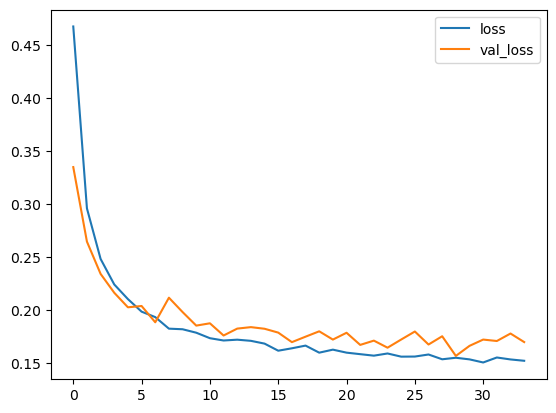

In [28]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()

In [29]:
y_pred_prob= model.predict(x_test_scaled)

328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step


In [30]:
y_pred_prob= y_pred_prob.reshape(10495,)

In [31]:
def exact(y_pred_prob):
    for i in range(len(y_pred_prob)):
        if y_pred_prob[i]>=0.5:
            y_pred_prob[i]=1
        else:
            y_pred_prob[i]=0
    return y_pred_prob

In [32]:
y_pred= exact(y_pred_prob)

In [33]:
accuracy_score(y_test, y_pred)

0.963315864697475

In [34]:
y_test

47655    0
16144    0
30588    0
29080    0
45602    0
        ..
29073    1
36090    0
43132    0
33886    1
47688    0
Name: PitStop, Length: 10495, dtype: int64